# Análisis Pokémon — Modelo Relacional (SQLite)

**Backend:** `data/pokemon.db` · 9 tablas SQLite · 1,350 Pokémon · 9 generaciones · 18 tipos

Este notebook analiza los datos Pokémon usando un modelo **relacional**: los datos están distribuidos en tablas conectadas por claves foráneas y se consultan con SQL + pandas.

## ¿Cuándo usar datos relacionales?
- Preguntas analíticas que cruzan varias entidades (promedios, correlaciones, agrupaciones)
- Cuando un cambio en un dato debe reflejarse en todas las consultas automáticamente
- Estadísticas, exploración, entrenamiento de modelos de ML

## Prerrequisitos
```bash
python scripts/fetch.py      # Descarga datos de PokéAPI (solo la primera vez)
python scripts/build_db.py   # Construye data/pokemon.db
```

---
**Secciones:** Explorador de tablas | Tipos | Atributos físicos | Stats (BST) | Legendarios | Efectividad | Combinaciones | Consultas SQL | Visor de Pokémon

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import numpy as np
from pathlib import Path

BG    = '#0f0f23'
PANEL = '#16213e'
FG    = '#e0e0e0'

matplotlib.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  PANEL,
    'axes.edgecolor':   '#444','axes.labelcolor': '#aaa',
    'xtick.color': FG,        'ytick.color':     FG,
    'text.color':  FG,        'grid.color':      '#2a2a4a',
    'grid.alpha':  0.7,
})

# Busca data/pokemon.db hacia arriba desde el CWD (funciona desde la raíz o desde notebooks/)
DB = next((p / 'data' / 'pokemon.db'
           for p in [Path.cwd(), *Path.cwd().parents]
           if (p / 'data' / 'pokemon.db').exists()), None)
assert DB is not None, 'No se encontró data/pokemon.db. Ejecuta: python scripts/build_db.py'
con = sqlite3.connect(DB)

TYPE_COLORS = {
    'normal':'#A8A77A',   'fire':'#EE8130',    'water':'#6390F0',
    'electric':'#F7D02C', 'grass':'#7AC74C',   'ice':'#96D9D6',
    'fighting':'#C22E28', 'poison':'#A33EA1',  'ground':'#E2BF65',
    'flying':'#A98FF3',   'psychic':'#F95587', 'bug':'#A6B91A',
    'rock':'#B6A136',     'ghost':'#735797',   'dragon':'#6F35FC',
    'dark':'#705746',     'steel':'#B7B7CE',   'fairy':'#D685AD',
}

TYPE_ES = {
    'normal':'Normal',      'fire':'Fuego',     'water':'Agua',
    'electric':'Electrico', 'grass':'Planta',   'ice':'Hielo',
    'fighting':'Lucha',     'poison':'Veneno',  'ground':'Tierra',
    'flying':'Volador',     'psychic':'Psiquico','bug':'Bicho',
    'rock':'Roca',          'ghost':'Fantasma', 'dragon':'Dragon',
    'dark':'Siniestro',     'steel':'Acero',    'fairy':'Hada',
}

STAT_COLS   = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
STAT_LABELS = ['HP', 'ATK', 'DEF', 'SP.ATK', 'SP.DEF', 'SPD']
GEN_MAP = {
    'generation-i':'Gen I',     'generation-ii':'Gen II',
    'generation-iii':'Gen III', 'generation-iv':'Gen IV',
    'generation-v':'Gen V',     'generation-vi':'Gen VI',
    'generation-vii':'Gen VII', 'generation-viii':'Gen VIII',
    'generation-ix':'Gen IX',
}
GEN_ORDER = ['Gen I','Gen II','Gen III','Gen IV','Gen V',
             'Gen VI','Gen VII','Gen VIII','Gen IX']

def bilabel(en):
    return TYPE_ES.get(en, en.title()) + ' / ' + en.title()

def badge_set(lbls, type_names, fontsize=9):
    for lbl, tipo in zip(lbls, type_names):
        c = TYPE_COLORS.get(tipo, '#777')
        lbl.set_bbox({'boxstyle':'round,pad=0.30', 'facecolor':c,
                      'edgecolor':'white', 'linewidth':0.5})
        lbl.set_color('white')
        lbl.set_fontsize(fontsize)
        lbl.set_fontweight('bold')

def clean_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333')
    ax.spines['bottom'].set_color('#333')

def minor_grid(ax, nx, ny):
    ax.set_xticks(np.arange(-0.5, nx, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ny, 1), minor=True)
    ax.grid(which='minor', color='#333', linewidth=0.6)
    ax.tick_params(which='minor', bottom=False, left=False)

print('Setup listo. DB conectada.')

Setup listo. DB conectada.


## 0. Explorador de Tablas

Antes de analizar, revisemos qué contiene cada tabla: cuántas filas tiene, qué columnas expone y cómo se distribuyen los valores clave.

In [2]:
# Mapa del esquema: tablas, filas y columnas disponibles
tablas = [
    'pokemon','pokemon_stats','pokemon_types','pokemon_abilities',
    'pokemon_moves','species','types','abilities','moves'
]
resumen = []
for t in tablas:
    sample = pd.read_sql(f'SELECT * FROM {t} LIMIT 1', con)
    n      = pd.read_sql(f'SELECT COUNT(*) as n FROM {t}', con).iloc[0, 0]
    resumen.append({'tabla': t, 'filas': n, 'columnas': len(sample.columns),
                    'campos': ', '.join(sample.columns)})
pd.DataFrame(resumen)

,tabla,filas,columnas,campos
0,pokemon,1350,6,"id, name, height, weight, base_experience, spr..."
1,pokemon_stats,8100,4,"pokemon_id, stat_name, base_value, effort"
2,pokemon_types,2115,3,"pokemon_id, type_name, slot"
3,pokemon_abilities,2926,4,"pokemon_id, ability_name, is_hidden, slot"
4,pokemon_moves,122446,4,"pokemon_id, move_name, learn_method, level_lea..."
5,species,1025,11,"id, name, color, shape, habitat, is_legendary,..."
6,types,21,7,"name, double_damage_to, half_damage_to, no_dam..."
7,abilities,371,2,"name, effect"
8,moves,937,6,"name, power, accuracy, pp, type_name, damage_c..."


In [3]:
# Muestra de las primeras filas de las tablas principales
from IPython.display import display
for t in ['pokemon', 'species', 'moves', 'abilities', 'types']:
    display(pd.read_sql(f'SELECT * FROM {t} LIMIT 5', con)
              .style.set_caption(t).set_table_styles(
                  [{'selector':'caption','props':[('color','#ffd700'),
                    ('font-size','13px'),('font-weight','bold')]}]))

,id,name,height,weight,base_experience,sprite_default
0,1,bulbasaur,7,69,64,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/1.png
1,2,ivysaur,10,130,142,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/2.png
2,3,venusaur,20,1000,236,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/3.png
3,4,charmander,6,85,62,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/4.png
4,5,charmeleon,11,190,142,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/5.png


,id,name,color,shape,habitat,is_legendary,is_mythical,generation,capture_rate,gender_rate,base_happiness
0,1,bulbasaur,green,quadruped,grassland,0,0,generation-i,45,1,70
1,2,ivysaur,green,quadruped,grassland,0,0,generation-i,45,1,70
2,3,venusaur,green,quadruped,grassland,0,0,generation-i,45,1,70
3,4,charmander,red,upright,mountain,0,0,generation-i,45,1,70
4,5,charmeleon,red,upright,mountain,0,0,generation-i,45,1,70


,name,power,accuracy,pp,type_name,damage_class
0,10-000-000-volt-thunderbolt,195.000000,nan,1,electric,special
1,absorb,20.000000,100.000000,25,grass,special
2,accelerock,40.000000,100.000000,20,rock,physical
3,acid-armor,nan,nan,20,poison,status
4,acid-downpour--physical,nan,nan,1,poison,physical


,name,effect
0,adaptability,"This Pokémon inflicts twice as much damage with moves whose types match its own, rather than the usual same-type attack bonus of 1.5×."
1,aerilate,Turns the bearer's Normal-type moves into Flying-type moves. Moves changed by this ability have 1.3× their power.
2,aftermath,"When this Pokémon is knocked out by a move that makes contact, the move's user takes 1/4 its maximum HP in damage."
3,air-lock,"While this Pokémon is in battle, weather can still be in play, but will not have any of its effects. This ability functions identically to Cloud Nine."
4,analytic,This Pokémon's moves have 1.3× their power when it moves last in a turn. Future Sight and Doom Desire are unaffected.


,name,double_damage_to,half_damage_to,no_damage_to,double_damage_from,half_damage_from,no_damage_from
0,bug,"grass,psychic,dark","fighting,flying,poison,ghost,steel,fire,fairy",,"flying,rock,fire","fighting,ground,grass",
1,dark,"ghost,psychic","fighting,dark,fairy",,"fighting,bug,fairy","ghost,dark",psychic
2,dragon,dragon,steel,fairy,"ice,dragon,fairy","fire,water,grass,electric",
3,electric,"flying,water","grass,electric,dragon",ground,ground,"flying,steel,electric",
4,fairy,"fighting,dragon,dark","poison,steel,fire",,"poison,steel","fighting,bug,dark",dragon


In [4]:
# Estadísticas descriptivas de columnas numéricas clave (pokemon + species)
df_explore = pd.read_sql('''
    SELECT p.height, p.weight, p.base_experience,
           s.capture_rate, s.base_happiness, s.gender_rate
    FROM pokemon p LEFT JOIN species s ON p.id = s.id
''', con)
df_explore.describe().round(1)

,height,weight,base_experience,capture_rate,base_happiness,gender_rate
count,1350.0,1350.0,1302.0,1025.0,1025.0,1025.0
mean,20.5,991.7,161.9,95.5,59.9,2.9
std,53.3,1953.7,82.5,76.0,22.5,2.2
min,1.0,0.0,36.0,3.0,0.0,-1.0
25%,6.0,94.2,71.0,45.0,50.0,1.0
50%,11.0,327.0,165.0,60.0,70.0,4.0
75%,17.0,854.2,222.5,140.0,70.0,4.0
max,1000.0,10000.0,608.0,255.0,140.0,8.0


In [5]:
# Valores nulos por columna — cuántos registros faltan y qué porcentaje representan
nulos = df_explore.isnull().sum().rename('nulos')
pct   = (df_explore.isnull().mean() * 100).round(1).rename('%')
pd.concat([nulos, pct], axis=1)

,nulos,%
height,0,0.0
weight,0,0.0
base_experience,48,3.6
capture_rate,325,24.1
base_happiness,325,24.1
gender_rate,325,24.1


In [6]:
# Distribución de valores categóricos clave
from IPython.display import display
for nombre, tabla, campo in [
    ('Generaciones',   'species',       'generation'),
    ('Colores',        'species',       'color'),
    ('Tipos únicos',   'pokemon_types', 'type_name'),
    ('Clases de daño', 'moves',         'damage_class'),
]:
    n = pd.read_sql(
        f'SELECT COUNT(DISTINCT {campo}) as n FROM {tabla}', con).iloc[0, 0]
    vals = pd.read_sql(
        f'SELECT {campo}, COUNT(*) as cnt FROM {tabla} '
        f'GROUP BY {campo} ORDER BY cnt DESC LIMIT 5', con)
    print(f'\n{nombre}  ({n} valores únicos):')
    display(vals)


Generaciones  (9 valores únicos):


,generation,cnt
0,generation-v,156
1,generation-i,151
2,generation-iii,135
3,generation-ix,120
4,generation-iv,107



Colores  (10 valores únicos):


,color,cnt
0,blue,170
1,brown,147
2,green,130
3,gray,107
4,red,97



Tipos únicos  (18 valores únicos):


,type_name,cnt
0,water,192
1,normal,160
2,grass,156
3,flying,154
4,psychic,141



Clases de daño  (3 valores únicos):


,damage_class,cnt
0,physical,395
1,status,277
2,special,265


## 1. Carga y Vista General del Dataset

> **Nota — formas base vs formas alternativas:**  
> La BD tiene 1 350 entradas en la tabla `pokemon`, pero **325 son formas alternativas**
> (mega, regional, gmax, formas de batalla: `deoxys-attack`, `giratina-origin`…).
> Estas formas usan `id ≥ 10 000` en PokéAPI. Los análisis de las secciones siguientes
> filtran a las **1 025 formas base** (`id < 10 000`) para que las estadísticas reflejen
> el Pokédex nacional real. Las formas siguen accesibles en el Visor (sección 9).


In [7]:
# Formas alternativas (mega, regional, gmax…) usan id >= 10000 en PokéAPI.
# Se filtran para que los análisis reflejen las 1025 formas base del Pokédex nacional.
pokemon  = pd.read_sql('SELECT * FROM pokemon WHERE id < 10000', con)
stats_l  = pd.read_sql('SELECT * FROM pokemon_stats', con)
species  = pd.read_sql('SELECT * FROM species', con)
tipos_db = pd.read_sql('SELECT * FROM pokemon_types', con)

stats = (stats_l
         .pivot(index='pokemon_id', columns='stat_name', values='base_value')
         .reset_index())
stats.columns.name = None

tipo1 = (tipos_db[tipos_db['slot']==1][['pokemon_id','type_name']]
         .rename(columns={'type_name':'type1'}))
tipo2 = (tipos_db[tipos_db['slot']==2][['pokemon_id','type_name']]
         .rename(columns={'type_name':'type2'}))

df = (pokemon
      .merge(stats, left_on='id', right_on='pokemon_id', how='left').drop(columns='pokemon_id')
      .merge(tipo1, left_on='id', right_on='pokemon_id', how='left').drop(columns='pokemon_id')
      .merge(tipo2, left_on='id', right_on='pokemon_id', how='left').drop(columns='pokemon_id')
      .merge(species[['id','is_legendary','is_mythical','generation',
                       'capture_rate','base_happiness']], on='id', how='left'))

df['bst']       = df[STAT_COLS].sum(axis=1)
df['categoria'] = 'Normal'
df.loc[df['is_legendary'] == 1, 'categoria'] = 'Legendario'
df.loc[df['is_mythical']  == 1, 'categoria'] = 'Mitico'
df['dual_tipo'] = df['type2'].notna()
df['height_m']  = df['height'] / 10
df['weight_kg'] = df['weight'] / 10
df['gen']       = df['generation'].map(GEN_MAP).fillna(df['generation'])

n_pok  = len(df)
n_leg  = (df['categoria']=='Legendario').sum()
n_mit  = (df['categoria']=='Mitico').sum()
n_dual = df['dual_tipo'].sum()

print('=' * 50)
print('  Total Pokemon    :', n_pok, '(formas base — excluye 325 formas alt.)')
print('  Generaciones     :', df['gen'].nunique())
print('  Legendarios      :', n_leg, ' | Miticos:', n_mit)
print('  Dual-tipo        :', n_dual, '(%s%%)' % round(n_dual/n_pok*100, 1))
print('  BST promedio     :', round(df['bst'].mean(), 1),
      ' | Mediana:', df['bst'].median())
print('=' * 50)
df[['id','name','type1','type2','bst','gen','categoria']].head(8)


  Total Pokemon    : 1025 (formas base — excluye 325 formas alt.)
  Generaciones     : 9
  Legendarios      : 71  | Miticos: 23
  Dual-tipo        : 526 (51.3%)
  BST promedio     : 427.7  | Mediana: 450.0


,id,name,type1,type2,bst,gen,categoria
0,1,bulbasaur,grass,poison,318,Gen I,Normal
1,2,ivysaur,grass,poison,405,Gen I,Normal
2,3,venusaur,grass,poison,525,Gen I,Normal
3,4,charmander,fire,NaN,309,Gen I,Normal
4,5,charmeleon,fire,NaN,405,Gen I,Normal
5,6,charizard,fire,flying,534,Gen I,Normal
6,7,squirtle,water,NaN,314,Gen I,Normal
7,8,wartortle,water,NaN,405,Gen I,Normal


## 2. Distribucion de Tipos Primarios
> Los **badges** de color son los colores canonicos de cada tipo en los juegos. Las etiquetas muestran el nombre en **Espanol / English** (oficial).

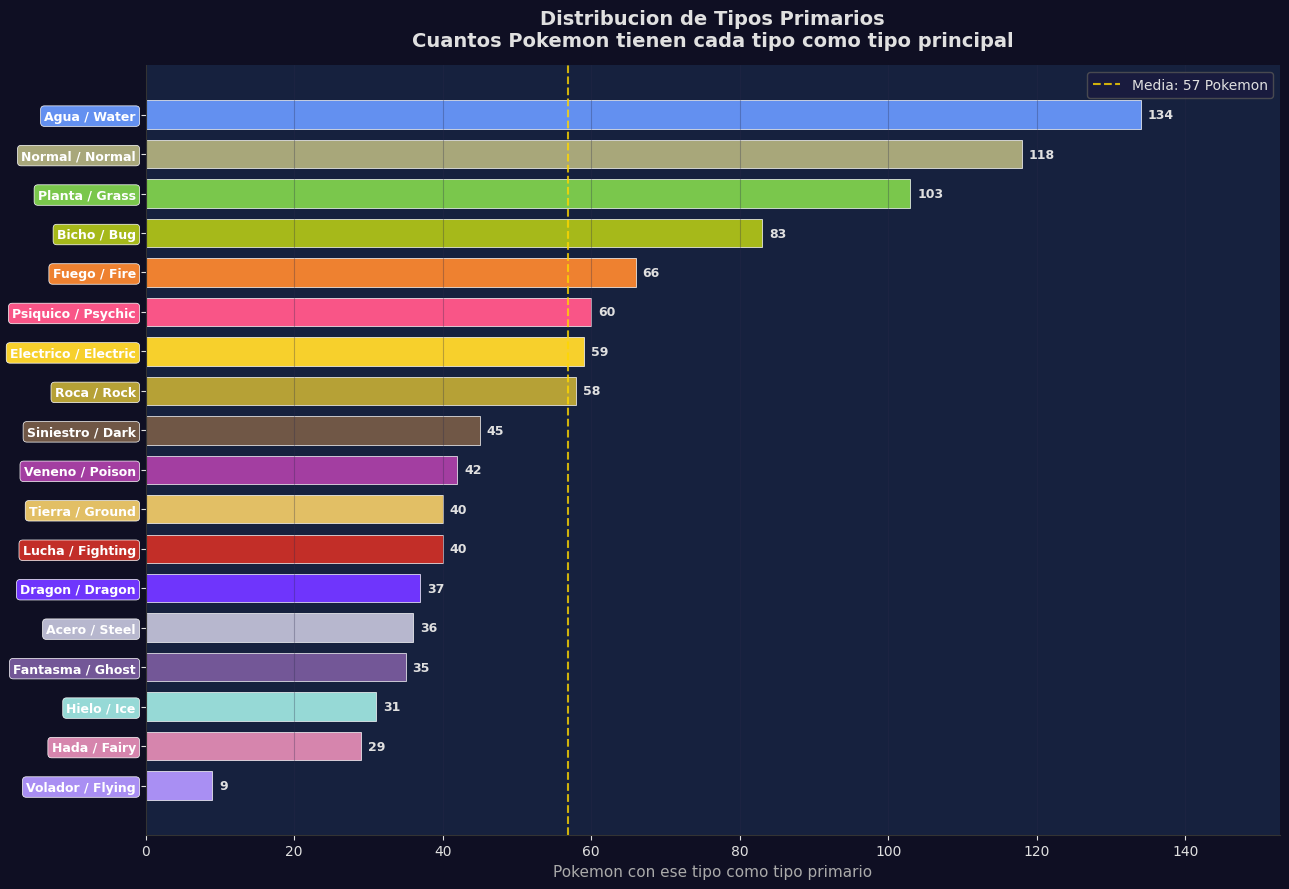

In [8]:
MAIN = sorted(TYPE_COLORS.keys())
type_counts = (df[df['type1'].isin(MAIN)]['type1']
               .value_counts()
               .reset_index()
               .rename(columns={'type1':'tipo', 'count':'n'})
               .sort_values('n'))

fig, ax = plt.subplots(figsize=(13, 9))
colors = [TYPE_COLORS[t] for t in type_counts['tipo']]
bars   = ax.barh(range(len(type_counts)), type_counts['n'],
                 color=colors, edgecolor='white', linewidth=0.5, height=0.72)
ax.bar_label(bars, fmt='%d', padding=5, fontsize=9, fontweight='bold')

ax.set_yticks(range(len(type_counts)))
lbls = ax.set_yticklabels([bilabel(t) for t in type_counts['tipo']])
badge_set(lbls, type_counts['tipo'].tolist(), fontsize=9)

media = type_counts['n'].mean()
ax.axvline(media, color='#ffd700', lw=1.5, ls='--', alpha=0.8,
           label='Media: %d Pokemon' % round(media))
ax.set_xlim(0, type_counts['n'].max() * 1.14)
clean_ax(ax)
ax.grid(axis='x', alpha=0.3)
ax.legend(facecolor='#1a1a3e', edgecolor='#555', fontsize=10)
ax.set_xlabel('Pokemon con ese tipo como tipo primario', fontsize=11)
ax.set_title('Distribucion de Tipos Primarios\nCuantos Pokemon tienen cada tipo como tipo principal',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


## 3. Atributos Fisicos — Peso y Altura

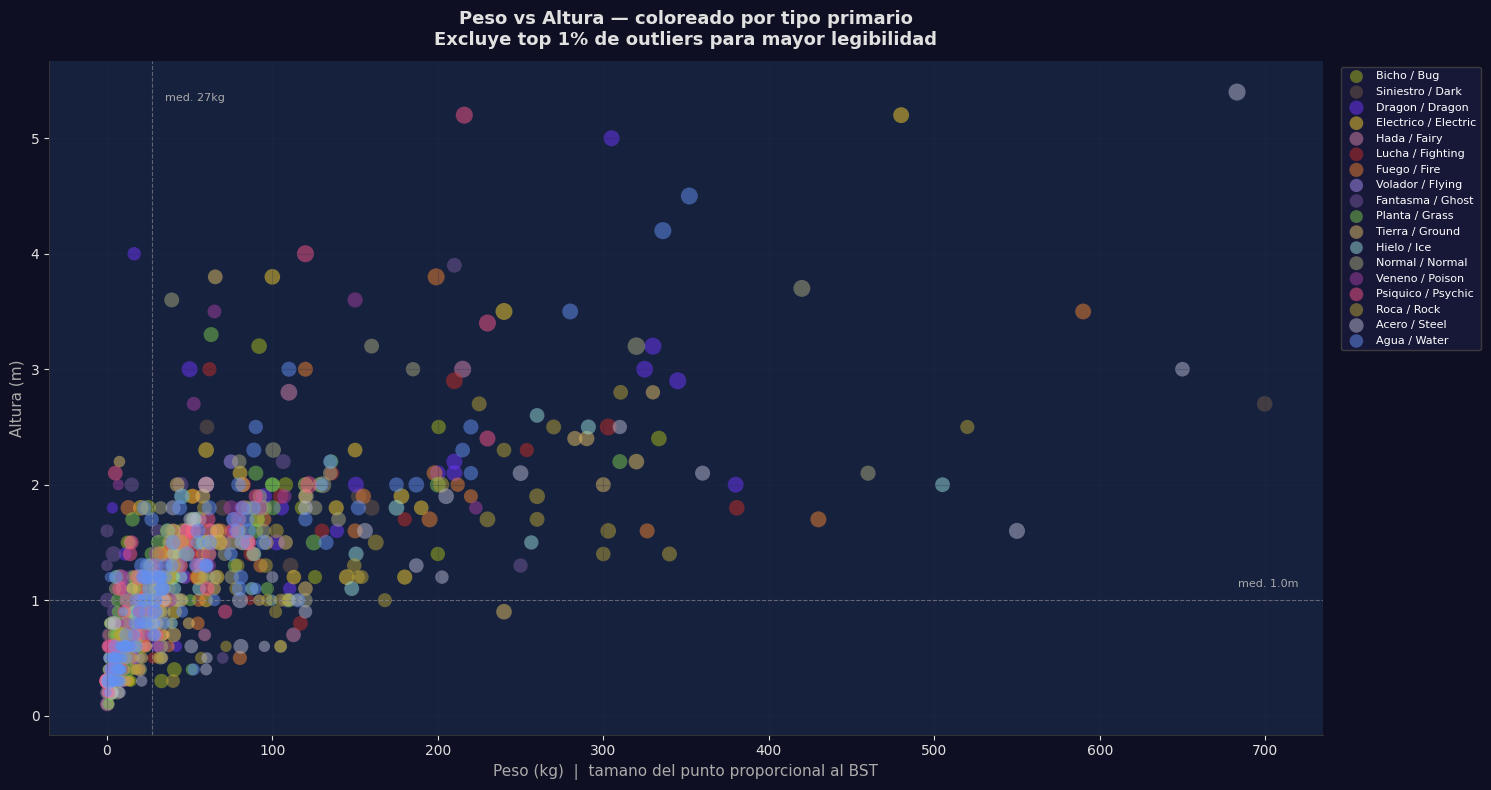

In [9]:
ds = df[df['type1'].isin(MAIN) & df['weight_kg'].notna() & df['height_m'].notna()].copy()
ds = ds[(ds['weight_kg'] <= ds['weight_kg'].quantile(0.99)) &
        (ds['height_m']  <= ds['height_m'].quantile(0.99))]

fig, ax = plt.subplots(figsize=(15, 8))
for tipo in MAIN:
    sub = ds[ds['type1'] == tipo]
    if sub.empty: continue
    ax.scatter(sub['weight_kg'], sub['height_m'],
               c=TYPE_COLORS[tipo], label=bilabel(tipo),
               alpha=0.50, s=sub['bst'] / 4.5, edgecolors='none')

mw = ds['weight_kg'].median()
mh = ds['height_m'].median()
ax.axhline(mh, color='#aaa', lw=0.8, ls='--', alpha=0.5)
ax.axvline(mw, color='#aaa', lw=0.8, ls='--', alpha=0.5)
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[1]*0.98, mh + (ylim[1]-ylim[0])*0.02,
        'med. %.1fm' % mh, ha='right', fontsize=8, color='#aaa')
ax.text(mw + (xlim[1]-xlim[0])*0.01, ylim[1]*0.94,
        'med. %.0fkg' % mw, fontsize=8, color='#aaa')

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8,
          facecolor='#1a1a3e', edgecolor='#444', labelcolor='white', ncol=1)
clean_ax(ax)
ax.grid(alpha=0.25)
ax.set_xlabel('Peso (kg)  |  tamano del punto proporcional al BST', fontsize=11)
ax.set_ylabel('Altura (m)', fontsize=11)
ax.set_title('Peso vs Altura — coloreado por tipo primario\nExcluye top 1% de outliers para mayor legibilidad',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


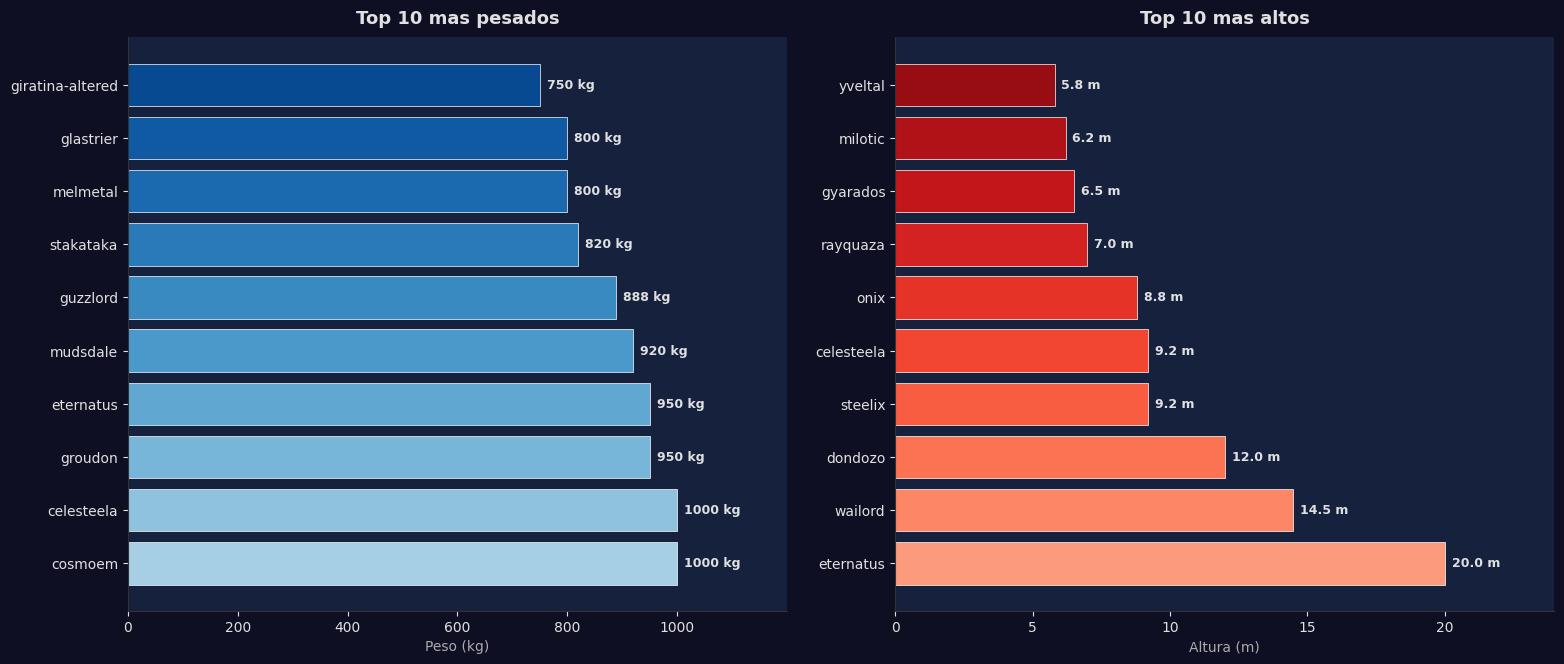

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, unit, title, cmap_name in [
    (axes[0], 'weight_kg', 'kg', 'Top 10 mas pesados', 'Blues'),
    (axes[1], 'height_m',  'm',  'Top 10 mas altos',  'Reds'),
]:
    top = df.nlargest(10, col)[['name', col]].set_index('name')
    colors_bar = getattr(plt.cm, cmap_name)(np.linspace(0.35, 0.9, 10))
    bars = ax.barh(top.index, top[col], color=colors_bar,
                   edgecolor='white', linewidth=0.5)
    fmt = '%.0f ' + unit if unit == 'kg' else '%.1f ' + unit
    ax.bar_label(bars, fmt=fmt, padding=5, fontsize=9, fontweight='bold')
    ax.set_xlim(0, top[col].max() * 1.20)
    clean_ax(ax)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Peso (kg)' if unit == 'kg' else 'Altura (m)', fontsize=10)

plt.tight_layout(pad=2)
plt.show()


## 4. Estadisticas Base (BST)

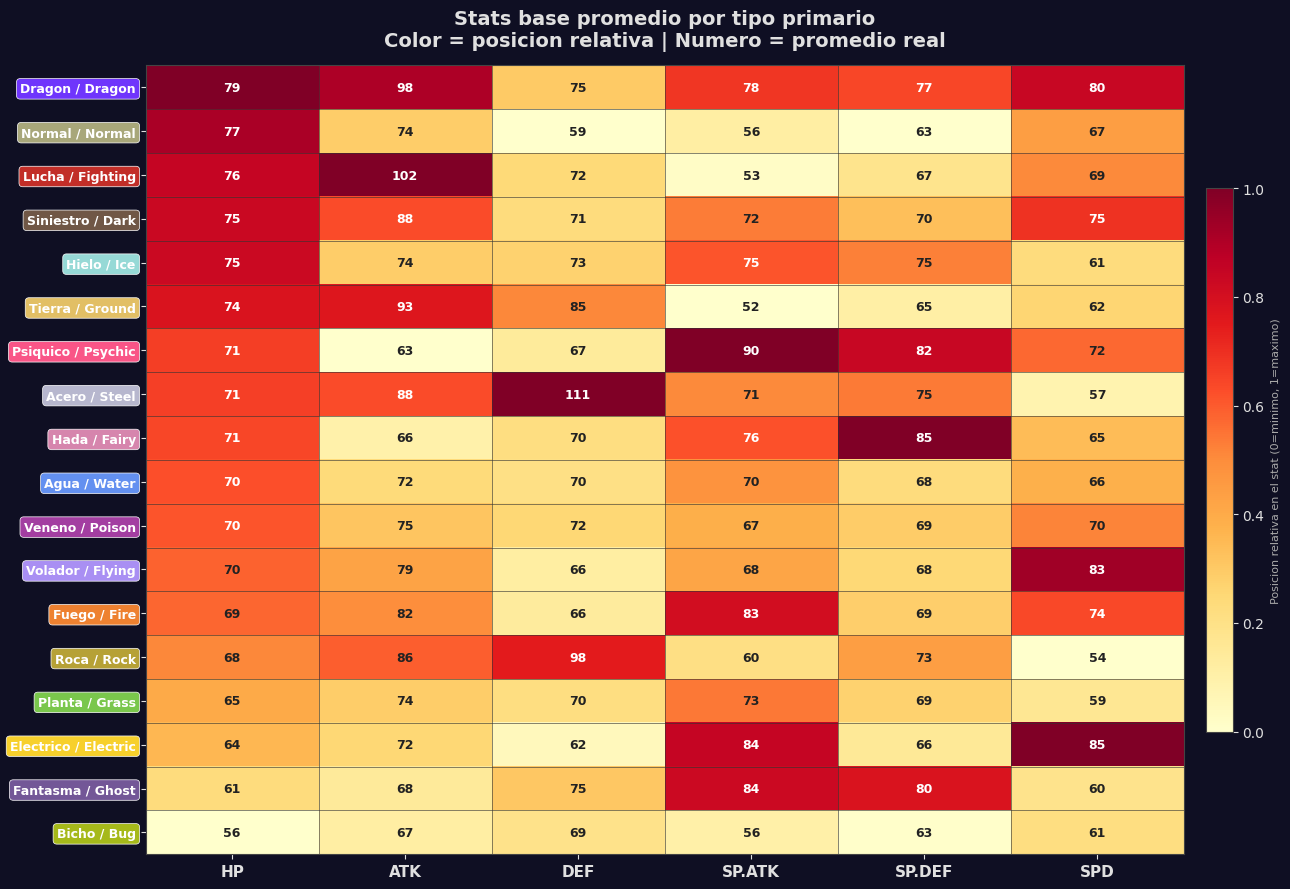

In [11]:
by_type = df[df['type1'].isin(MAIN)].groupby('type1')[STAT_COLS].mean()
normed  = (by_type - by_type.min()) / (by_type.max() - by_type.min())
normed  = normed.sort_values('hp', ascending=False)
raw     = by_type.loc[normed.index]
types_s = normed.index.tolist()

fig, ax = plt.subplots(figsize=(13, 9))
im = ax.imshow(normed.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

for i, tipo in enumerate(types_s):
    for j in range(len(STAT_COLS)):
        val  = raw.loc[tipo, STAT_COLS[j]]
        norm = normed.loc[tipo, STAT_COLS[j]]
        tc   = 'white' if norm > 0.60 else '#222'
        ax.text(j, i, '%d' % val, ha='center', va='center',
                fontsize=9, fontweight='bold', color=tc)

ax.set_xticks(range(len(STAT_COLS)))
ax.set_xticklabels(STAT_LABELS, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(types_s)))
lbls = ax.set_yticklabels([bilabel(t) for t in types_s])
badge_set(lbls, types_s, fontsize=9)

cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.ax.set_ylabel('Posicion relativa en el stat (0=minimo, 1=maximo)', fontsize=8)
minor_grid(ax, len(STAT_COLS), len(types_s))
ax.set_title('Stats base promedio por tipo primario\nColor = posicion relativa | Numero = promedio real',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


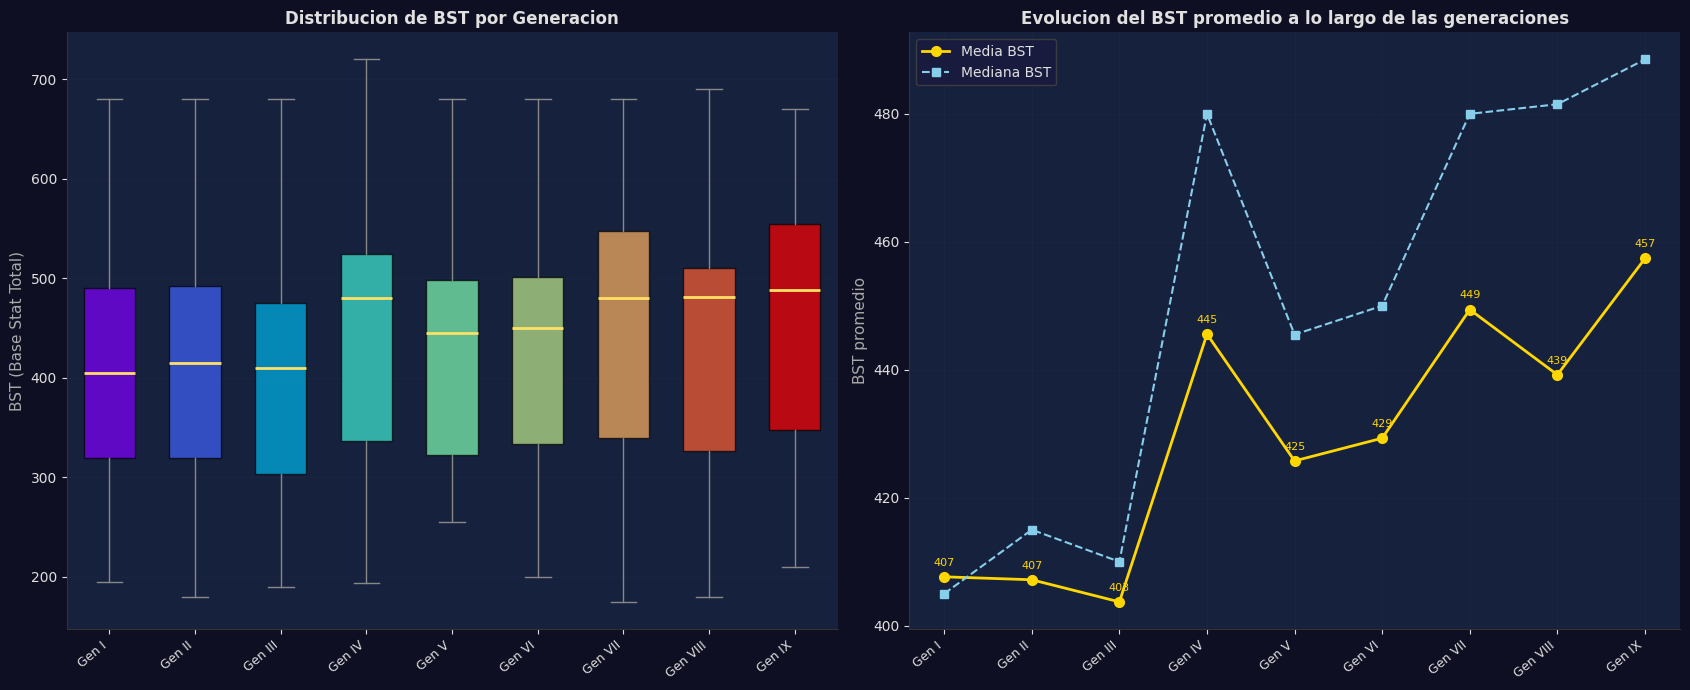

In [12]:
df_gen = df[df['gen'].isin(GEN_ORDER)].copy()
gen_colors = plt.cm.rainbow(np.linspace(0, 1, len(GEN_ORDER)))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Boxplot ---
ax = axes[0]
data_per_gen = [df_gen[df_gen['gen'] == g]['bst'].dropna().values for g in GEN_ORDER]
bp = ax.boxplot(data_per_gen, vert=True, patch_artist=True,
                positions=range(len(GEN_ORDER)), widths=0.6,
                medianprops={'color':'#ffe066','linewidth':2},
                whiskerprops={'color':'#888'}, capprops={'color':'#888'},
                flierprops={'marker':'.','color':'#aaa','markersize':3,'alpha':0.5})
for patch, c in zip(bp['boxes'], gen_colors):
    patch.set_facecolor(c); patch.set_alpha(0.70)
ax.set_xticks(range(len(GEN_ORDER)))
ax.set_xticklabels(GEN_ORDER, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('BST (Base Stat Total)', fontsize=11)
ax.set_title('Distribucion de BST por Generacion', fontsize=12, fontweight='bold')
clean_ax(ax); ax.grid(axis='y', alpha=0.3)

# --- Tendencia media ---
ax2 = axes[1]
sg = df_gen.groupby('gen')['bst'].agg(['mean','median','count']).reindex(GEN_ORDER).dropna()
x  = list(range(len(sg)))
ax2.plot(x, sg['mean'],   'o-', color='#ffd700', lw=2, ms=7, label='Media BST')
ax2.plot(x, sg['median'], 's--', color='#87ceeb', lw=1.5, ms=6, label='Mediana BST')
for i, (gen, row) in enumerate(sg.iterrows()):
    ax2.annotate('%d' % row['mean'], (i, row['mean']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color='#ffd700')
    ax2.annotate('n=%d' % row['count'], (i, sg['mean'].min() - 18),
                 ha='center', fontsize=7, color='#888')
ax2.set_xticks(range(len(sg)))
ax2.set_xticklabels(sg.index, rotation=40, ha='right', fontsize=9)
ax2.set_ylabel('BST promedio', fontsize=11)
ax2.set_title('Evolucion del BST promedio a lo largo de las generaciones',
              fontsize=12, fontweight='bold')
ax2.legend(facecolor='#1a1a3e', edgecolor='#444', fontsize=10)
clean_ax(ax2); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


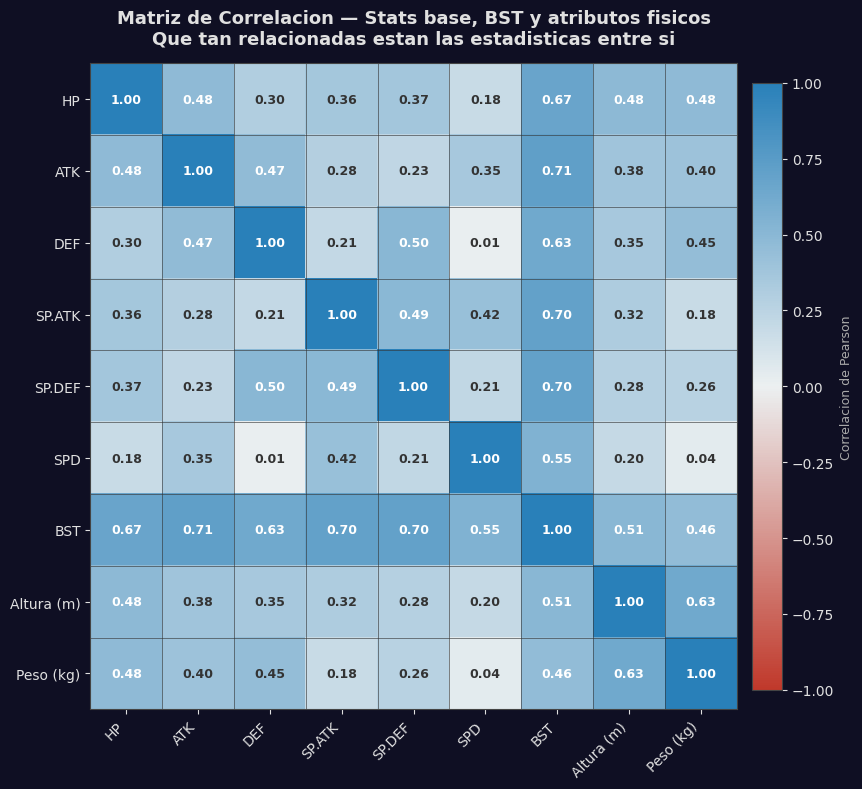

In [13]:
cols_c = STAT_COLS + ['bst', 'height_m', 'weight_kg']
labs_c = STAT_LABELS + ['BST', 'Altura (m)', 'Peso (kg)']
corr   = df[cols_c].corr()

cmap_c = LinearSegmentedColormap.from_list('corr', ['#c0392b','#ecf0f1','#2980b9'])
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap=cmap_c, vmin=-1, vmax=1, aspect='equal')

n = len(labs_c)
for i in range(n):
    for j in range(n):
        v  = corr.values[i, j]
        tc = 'white' if abs(v) > 0.45 else '#333'
        ax.text(j, i, '%.2f' % v, ha='center', va='center',
                fontsize=9, fontweight='bold', color=tc)

ax.set_xticks(range(n)); ax.set_xticklabels(labs_c, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(labs_c, fontsize=10)
minor_grid(ax, n, n)

cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.ax.set_ylabel('Correlacion de Pearson', fontsize=9)
ax.set_title('Matriz de Correlacion — Stats base, BST y atributos fisicos\nQue tan relacionadas estan las estadisticas entre si',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


## 5. Legendarios, Miticos y Normales

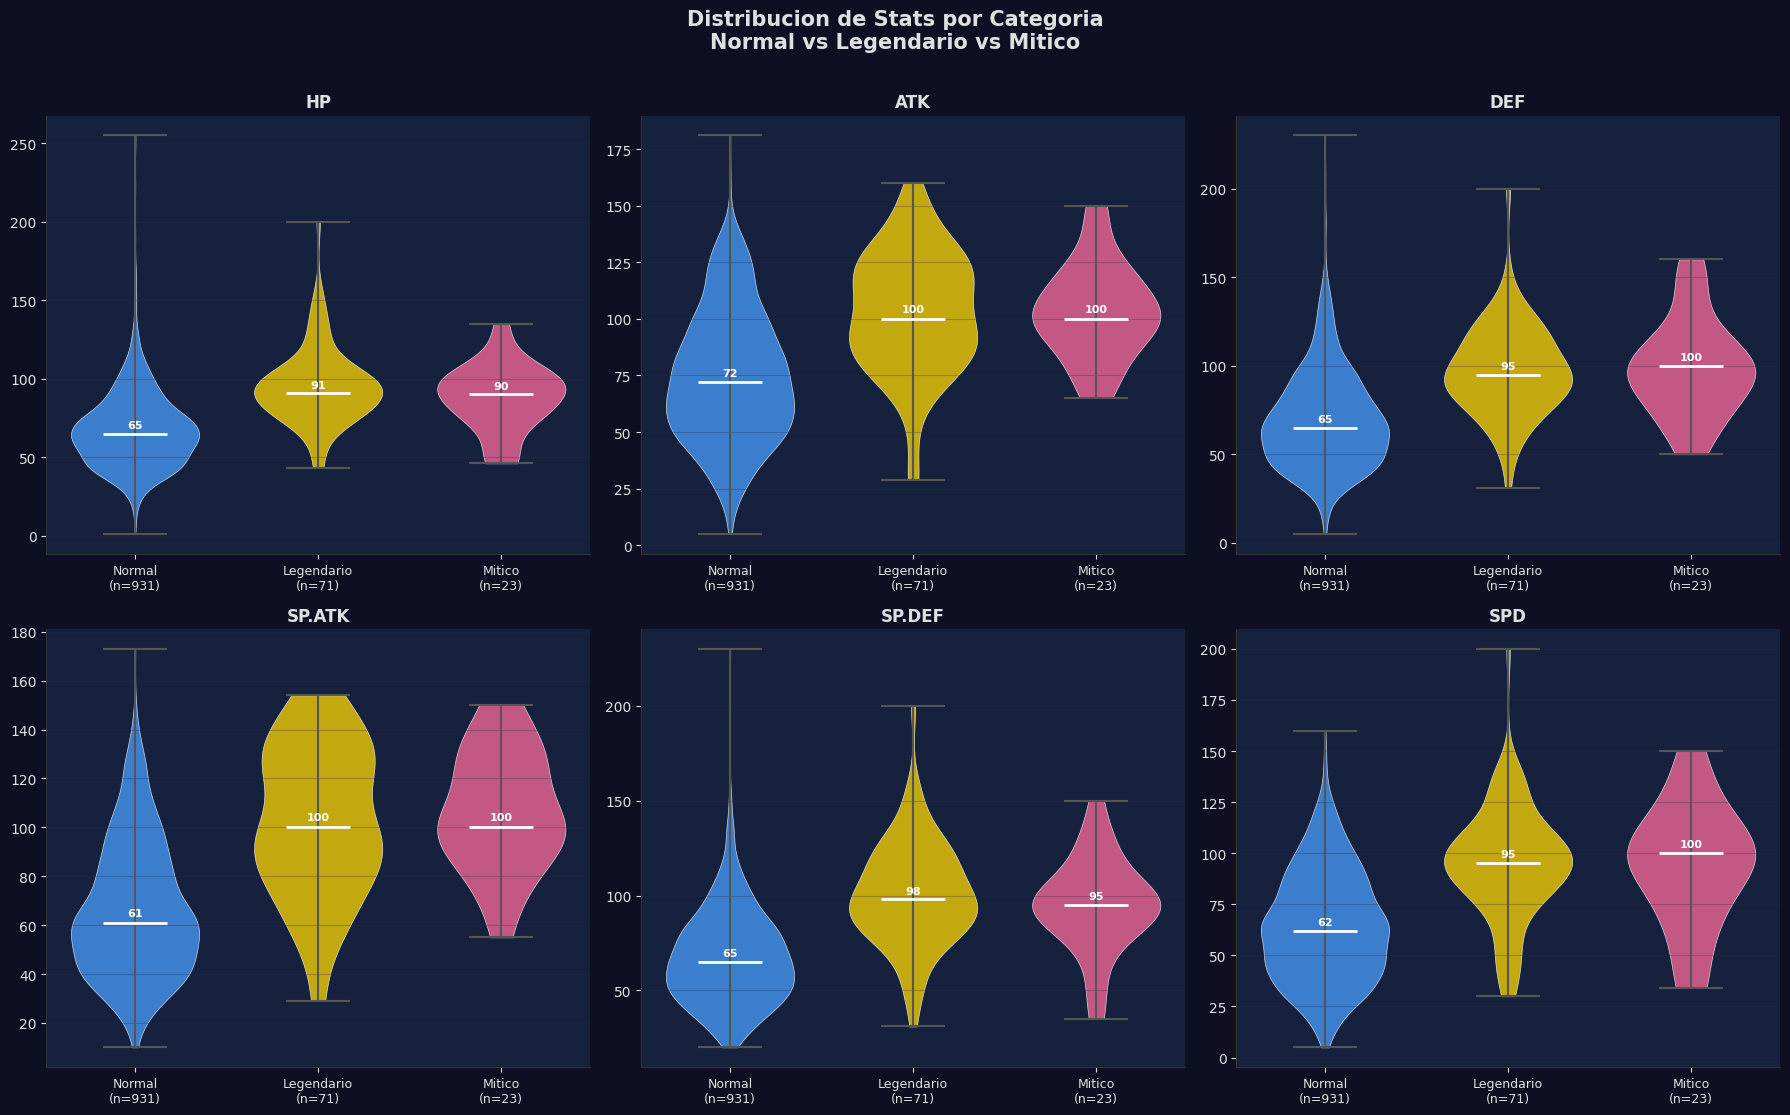

In [14]:
cats       = ['Normal', 'Legendario', 'Mitico']
cat_colors = {'Normal':'#4a9eff', 'Legendario':'#ffd700', 'Mitico':'#ff6b9d'}
counts_cat = df['categoria'].value_counts()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Distribucion de Stats por Categoria\nNormal vs Legendario vs Mitico',
             fontsize=15, fontweight='bold', y=1.01)

for idx, (stat, label) in enumerate(zip(STAT_COLS, STAT_LABELS)):
    ax = axes[idx // 3][idx % 3]
    groups = [df[df['categoria'] == cat][stat].dropna().values for cat in cats]
    valid_pos  = [i for i, g in enumerate(groups) if len(g) >= 2]
    valid_data = [groups[i] for i in valid_pos]
    valid_cats = [cats[i]   for i in valid_pos]

    if valid_data:
        parts = ax.violinplot(valid_data, positions=valid_pos,
                              showmedians=True, showextrema=True, widths=0.70)
        for body, cat in zip(parts['bodies'], valid_cats):
            body.set_facecolor(cat_colors[cat])
            body.set_alpha(0.75)
            body.set_edgecolor('white')
            body.set_linewidth(0.5)
        parts['cmedians'].set_color('#ffffff')
        parts['cmedians'].set_linewidth(2)
        for key in ('cbars','cmins','cmaxes'):
            parts[key].set_color('#555')
        for i, (cat, d) in enumerate(zip(valid_cats, valid_data)):
            if len(d):
                ax.text(i, float(np.median(d)) + 2, '%d' % np.median(d),
                        ha='center', va='bottom', fontsize=8,
                        color='white', fontweight='bold')

    n_labels = [cat + '\n(n=%d)' % counts_cat.get(cat, 0) for cat in cats]
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(n_labels, fontsize=9)
    ax.set_title(label, fontsize=12, fontweight='bold')
    clean_ax(ax); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Efectividad de Tipos

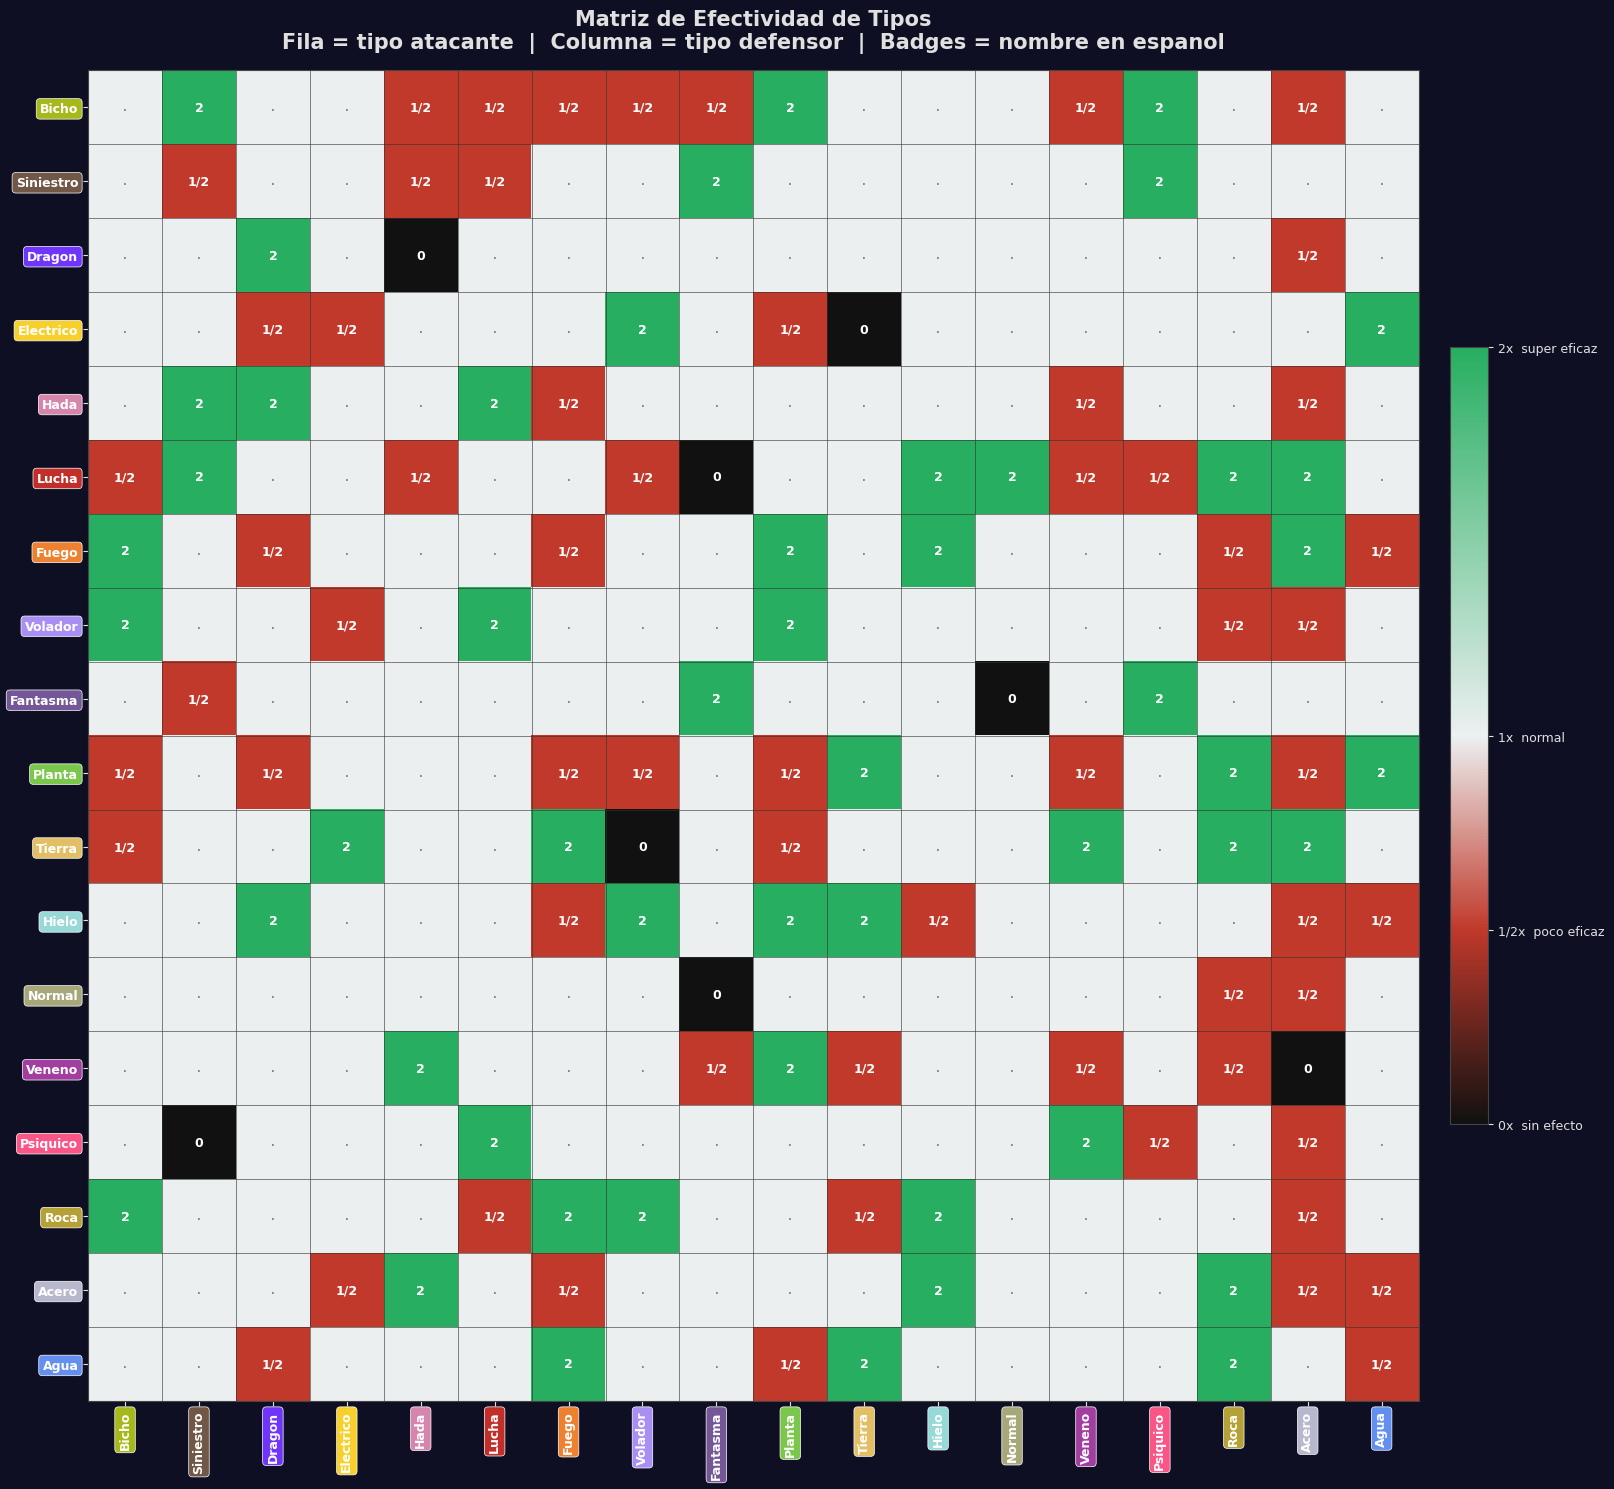

In [15]:
types_df  = pd.read_sql('SELECT * FROM types', con)
all_types = sorted(t for t in types_df['name'].tolist() if t in TYPE_COLORS)
matrix    = pd.DataFrame(1.0, index=all_types, columns=all_types)

for _, row in types_df.iterrows():
    atk = row['name']
    if atk not in matrix.index: continue
    for col_field, val in [('double_damage_to', 2.0),
                            ('half_damage_to',   0.5),
                            ('no_damage_to',     0.0)]:
        for t in (row[col_field] or '').split(','):
            t = t.strip()
            if t in matrix.columns:
                matrix.loc[atk, t] = val

cmap_eff = LinearSegmentedColormap.from_list(
    'poke_eff',
    [(0.00, '#111111'), (0.25, '#c0392b'), (0.50, '#ecf0f1'), (1.00, '#27ae60')])

fig, ax = plt.subplots(figsize=(17, 15))
im = ax.imshow(matrix.values, cmap=cmap_eff, vmin=0, vmax=2, aspect='equal')

ANNOT = {0.0:'0', 0.5:'1/2', 1.0:'.', 2.0:'2'}
for i in range(len(all_types)):
    for j in range(len(all_types)):
        v  = matrix.iloc[i, j]
        tc = 'white' if v != 1.0 else '#888'
        sz = 9 if v != 1.0 else 7
        ax.text(j, i, ANNOT[v], ha='center', va='center',
                fontsize=sz, fontweight='bold', color=tc)

ax.set_xticks(range(len(all_types)))
ax.set_yticks(range(len(all_types)))
xlbls = ax.set_xticklabels([TYPE_ES.get(t, t) for t in all_types], rotation=90, fontsize=9)
ylbls = ax.set_yticklabels([TYPE_ES.get(t, t) for t in all_types], fontsize=9)
badge_set(xlbls, all_types, fontsize=9)
badge_set(ylbls, all_types, fontsize=9)
minor_grid(ax, len(all_types), len(all_types))

cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, ticks=[0, 0.5, 1, 2])
cb.ax.set_yticklabels(['0x  sin efecto', '1/2x  poco eficaz',
                        '1x  normal', '2x  super eficaz'], fontsize=9)
ax.set_title('Matriz de Efectividad de Tipos\n'
             'Fila = tipo atacante  |  Columna = tipo defensor  |  Badges = nombre en espanol',
             fontsize=15, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()


## 7. Combinaciones de Tipos

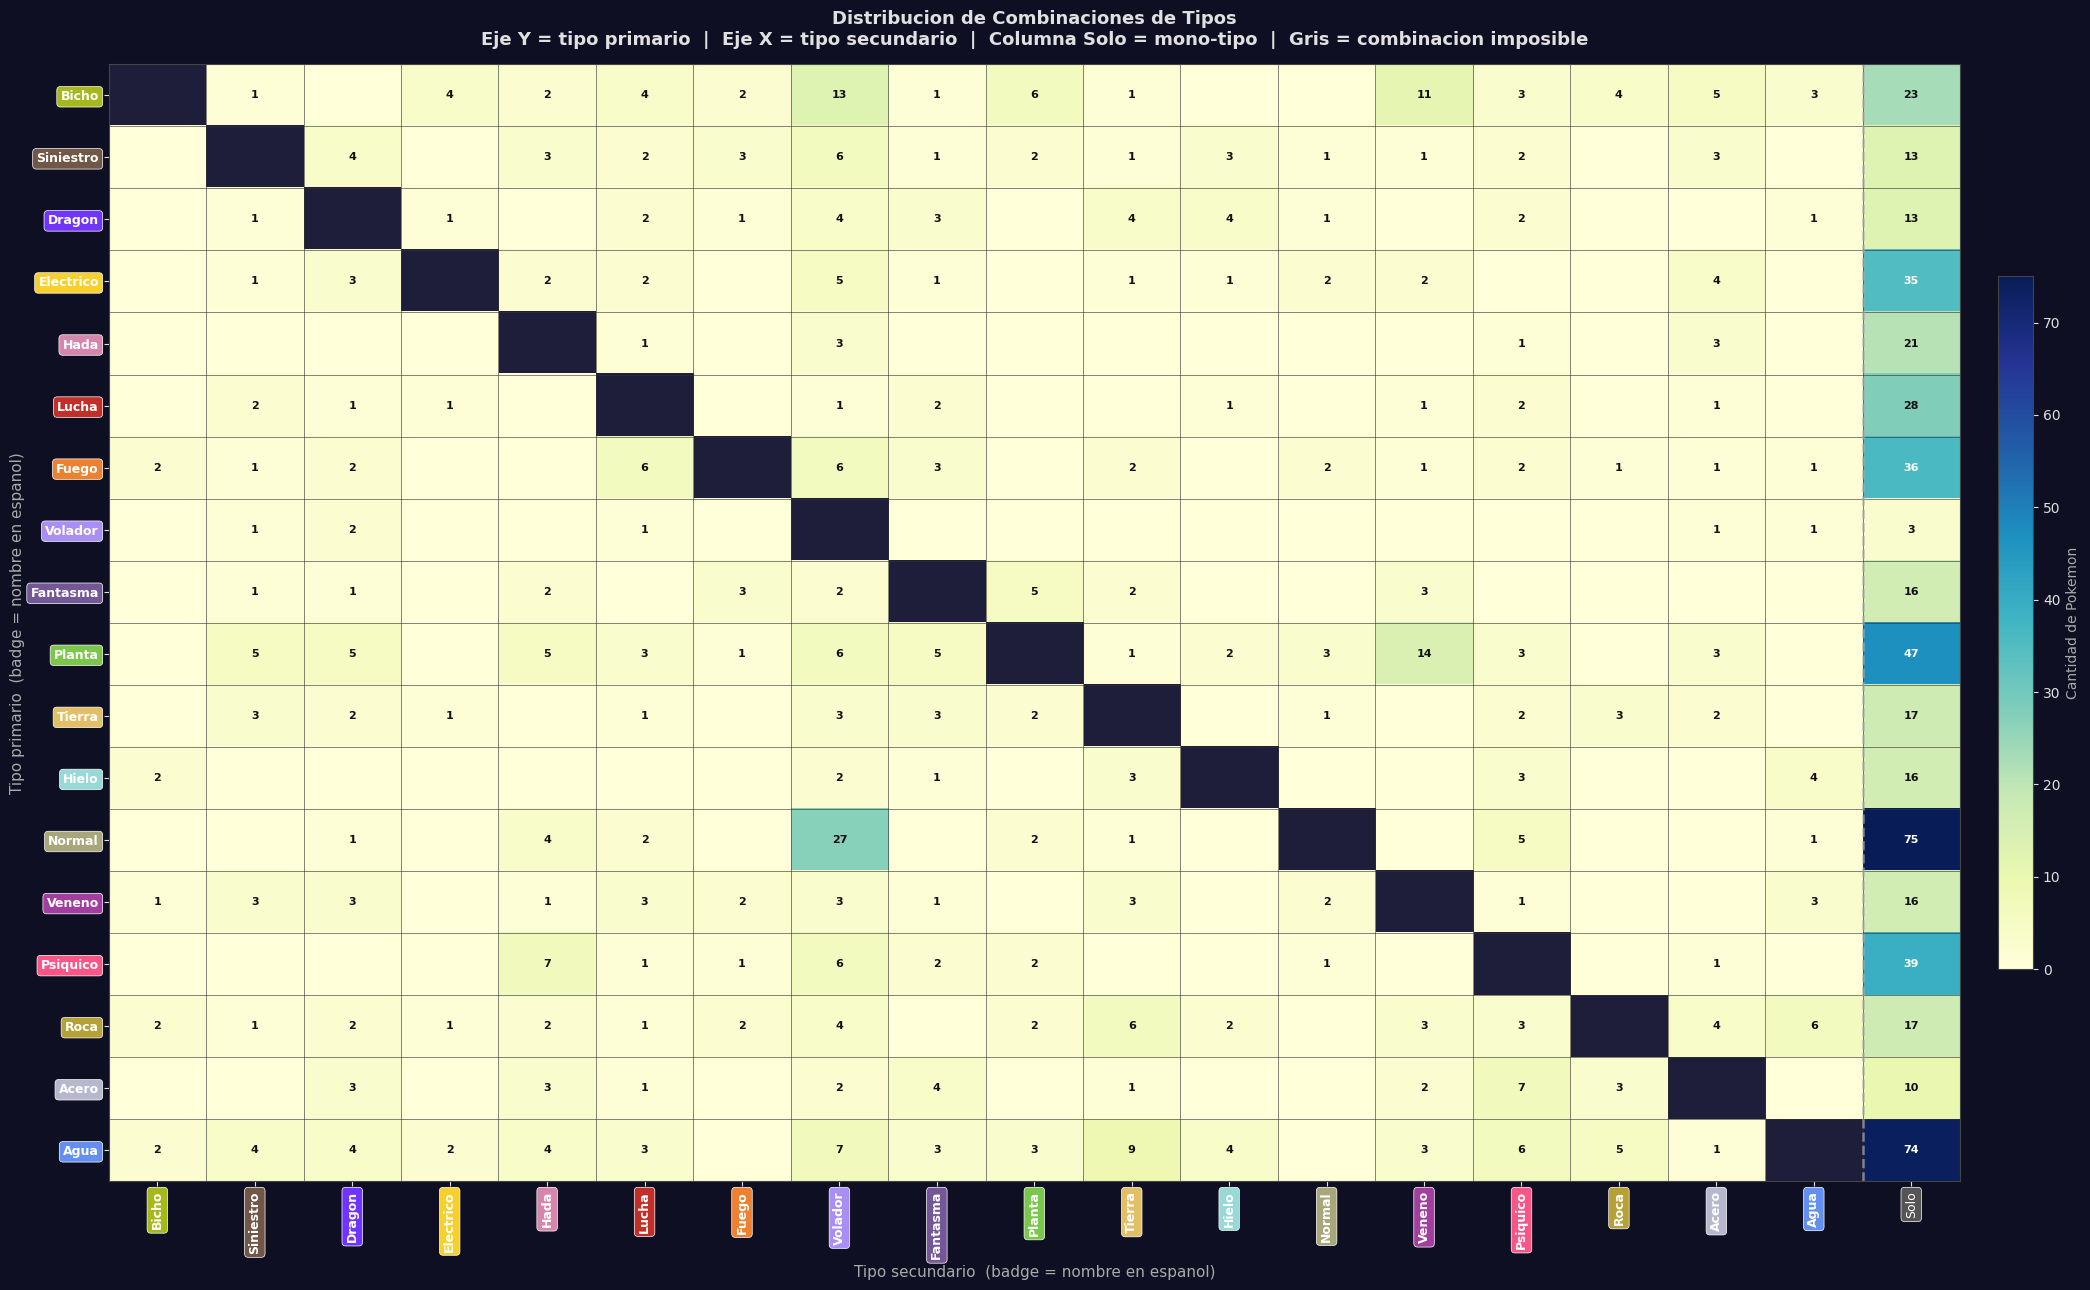

In [16]:
tipo1_df = pd.read_sql('SELECT pokemon_id, type_name FROM pokemon_types WHERE slot=1 AND pokemon_id < 10000', con)
tipo2_df = pd.read_sql('SELECT pokemon_id, type_name FROM pokemon_types WHERE slot=2 AND pokemon_id < 10000', con)
comb = tipo1_df.merge(tipo2_df, on='pokemon_id', how='left', suffixes=('_1','_2'))
comb['t2'] = comb['type_name_2'].fillna('solo')

all_t      = sorted(TYPE_COLORS.keys())
sec_labels = all_t + ['solo']
mat = pd.DataFrame(0, index=all_t, columns=sec_labels, dtype=float)

for _, row in comb.iterrows():
    t1, t2 = row['type_name_1'], row['t2']
    if t1 in mat.index and t2 in mat.columns:
        mat.loc[t1, t2] += 1

data = mat.values.copy()
for i, t in enumerate(all_t):
    j = sec_labels.index(t)
    if mat.loc[t, t] == 0:
        data[i, j] = np.nan

cmap2 = plt.cm.YlGnBu.copy()
cmap2.set_bad('#1e1e3a')
vmax = float(np.nanmax(data))

fig, ax = plt.subplots(figsize=(21, 13))
im2 = ax.imshow(data, cmap=cmap2, aspect='auto', vmin=0, vmax=vmax)

for i in range(len(all_t)):
    for j in range(len(sec_labels)):
        v = int(mat.iloc[i, j])
        if v > 0:
            norm_v = v / vmax
            tc = 'white' if norm_v > 0.45 else '#111'
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=8, fontweight='bold', color=tc)

ax.set_xticks(range(len(sec_labels)))
ax.set_yticks(range(len(all_t)))
xlbls2 = ax.set_xticklabels(
    [TYPE_ES.get(t, t) if t != 'solo' else 'Solo' for t in sec_labels],
    rotation=90, fontsize=9)
ylbls2 = ax.set_yticklabels([TYPE_ES.get(t, t) for t in all_t], fontsize=9)
badge_set(xlbls2[:-1], all_t, fontsize=9)
badge_set(ylbls2, all_t, fontsize=9)
xlbls2[-1].set_bbox({'boxstyle':'round,pad=0.30','facecolor':'#555',
                     'edgecolor':'white','linewidth':0.5})
xlbls2[-1].set_color('white')

ax.axvline(x=len(all_t) - 0.5, color='#aaa', lw=1.8, ls='--', alpha=0.7)
minor_grid(ax, len(sec_labels), len(all_t))

cb2 = plt.colorbar(im2, ax=ax, fraction=0.018, pad=0.02)
cb2.ax.set_ylabel('Cantidad de Pokemon', fontsize=10)
ax.set_title('Distribucion de Combinaciones de Tipos\n'
             'Eje Y = tipo primario  |  Eje X = tipo secundario  |  '
             'Columna Solo = mono-tipo  |  Gris = combinacion imposible',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Tipo secundario  (badge = nombre en espanol)', fontsize=11)
ax.set_ylabel('Tipo primario  (badge = nombre en espanol)', fontsize=11)
plt.tight_layout()
plt.show()


## 8. Consultas SQL Personalizadas

In [17]:
pd.read_sql('''
    SELECT name, type_name AS tipo, power AS poder,
           accuracy AS precision, pp, damage_class AS clase
    FROM moves
    WHERE power IS NOT NULL
    ORDER BY power DESC
    LIMIT 15
''', con)


,name,tipo,poder,precision,pp,clase
0,explosion,normal,250,100.0,5,physical
1,catastropika,electric,210,NaN,1,physical
2,pulverizing-pancake,normal,210,NaN,1,physical
3,light-that-burns-the-sky,psychic,200,NaN,1,special
4,menacing-moonraze-maelstrom,ghost,200,NaN,1,special
5,searing-sunraze-smash,steel,200,NaN,1,physical
6,self-destruct,normal,200,100.0,5,physical
7,10-000-000-volt-thunderbolt,electric,195,NaN,1,special
8,oceanic-operetta,water,195,NaN,1,special
9,soul-stealing-7-star-strike,ghost,195,NaN,1,physical


In [18]:
pd.read_sql('''
    SELECT pt.type_name AS tipo, sp.generation AS generacion,
           ROUND(AVG(sp.capture_rate), 1) AS captura_promedio,
           COUNT(*) AS n_pokemon
    FROM pokemon_types pt
    JOIN species sp ON pt.pokemon_id = sp.id
    WHERE pt.slot = 1 AND sp.capture_rate IS NOT NULL
    GROUP BY pt.type_name, sp.generation
    ORDER BY captura_promedio ASC
    LIMIT 20
''', con)


,tipo,generacion,captura_promedio,n_pokemon
0,flying,generation-v,3.0,1
1,steel,generation-vii,13.5,4
2,ice,generation-i,24.0,2
3,steel,generation-ii,25.0,2
4,dark,generation-iv,26.0,3
5,fairy,generation-iv,30.0,1
6,fighting,generation-ix,32.7,3
7,dragon,generation-iii,33.0,7
8,dragon,generation-v,33.4,7
9,fire,generation-iv,33.6,5


## 9. Visor de Pokémon — Ficha Individual

Busca cualquier Pokémon por **nombre** o **ID** para ver su sprite, tipos, stats y datos clave.  
Útil para verificar tipos de Pokémon específicos directamente desde la base de datos.

In [19]:
import urllib.request
from io import BytesIO
import matplotlib.image as mpimg

def ver_pokemon(nombre_o_id):
    """
    Muestra la ficha completa de un Pokémon.
    Uso: ver_pokemon('charizard')  o  ver_pokemon(6)
    """
    if isinstance(nombre_o_id, int):
        where = f"p.id = {nombre_o_id}"
    else:
        safe = nombre_o_id.lower().strip().replace("'", "")
        where = f"LOWER(p.name) = '{safe}'"

    df_p = pd.read_sql(f'''
        SELECT p.id, p.name, p.height, p.weight, p.base_experience, p.sprite_default,
               sp.generation, sp.color, sp.is_legendary, sp.is_mythical,
               sp.capture_rate, sp.base_happiness
        FROM pokemon p
        LEFT JOIN species sp ON p.id = sp.id
        WHERE {where}
        LIMIT 1
    ''', con)

    if df_p.empty:
        print(f"No se encontró: {nombre_o_id}")
        return

    poke = df_p.iloc[0]
    pid  = int(poke['id'])

    stats_q = pd.read_sql(
        f'SELECT stat_name, base_value FROM pokemon_stats WHERE pokemon_id={pid}', con)
    stats_d = dict(zip(stats_q['stat_name'], stats_q['base_value']))

    types_q = pd.read_sql(
        f'SELECT type_name, slot FROM pokemon_types WHERE pokemon_id={pid} ORDER BY slot', con)
    tipos = types_q['type_name'].tolist()

    abil_q = pd.read_sql(
        f'SELECT ability_name, is_hidden FROM pokemon_abilities WHERE pokemon_id={pid} ORDER BY slot', con)

    # ---- Layout ----
    fig = plt.figure(figsize=(15, 6), facecolor=BG)
    gs  = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.8, 1.1], wspace=0.32)

    # -------- Sprite + tipos --------
    ax_s = fig.add_subplot(gs[0])
    ax_s.set_facecolor(PANEL)
    ax_s.axis('off')

    sprite_url = poke.get('sprite_default')
    if sprite_url:
        try:
            with urllib.request.urlopen(sprite_url, timeout=6) as resp:
                img = mpimg.imread(BytesIO(resp.read()), format='png')
            ax_s.imshow(img, interpolation='nearest')
        except Exception:
            ax_s.text(0.5, 0.5, '(sin sprite)', ha='center', va='center',
                      transform=ax_s.transAxes, color='#888', fontsize=10)

    # Tipos como badges bajo el sprite
    tipo_text = '  +  '.join(t.upper() for t in tipos)
    tipo_color = TYPE_COLORS.get(tipos[0], '#777') if tipos else '#777'

    cat = ('Mítico'     if poke.get('is_mythical')  else
           'Legendario' if poke.get('is_legendary') else 'Normal')
    cat_color = {'Mítico': '#ff6b9d', 'Legendario': '#ffd700', 'Normal': '#4a9eff'}[cat]
    gen_label = GEN_MAP.get(poke.get('generation', ''), poke.get('generation', '—'))

    ax_s.set_title(
        f"#{pid}  {poke['name'].title()}\n"
        f"{gen_label}  ·  {cat}",
        fontsize=12, fontweight='bold', color=FG, pad=6)

    # Etiqueta de tipos con fondo coloreado
    for k, tipo in enumerate(tipos):
        ax_s.text(
            0.5, -0.07 - k * 0.10, tipo.upper(),
            ha='center', va='top', transform=ax_s.transAxes,
            fontsize=11, fontweight='bold', color='white',
            bbox={'boxstyle': 'round,pad=0.35',
                  'facecolor': TYPE_COLORS.get(tipo, '#777'),
                  'edgecolor': 'white', 'linewidth': 0.8})

    # -------- Stats --------
    ax_b = fig.add_subplot(gs[1])
    ax_b.set_facecolor(PANEL)

    stat_vals   = [stats_d.get(s, 0) for s in STAT_COLS]
    bar_palette = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71', '#9b59b6']
    bars = ax_b.barh(range(len(STAT_COLS)), stat_vals, color=bar_palette,
                     edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, stat_vals):
        ax_b.text(val + 3, bar.get_y() + bar.get_height() / 2,
                  str(val), va='center', fontsize=10, fontweight='bold', color=FG)

    bst = sum(stat_vals)
    ax_b.set_yticks(range(len(STAT_COLS)))
    ax_b.set_yticklabels(STAT_LABELS, fontsize=10)
    ax_b.set_xlim(0, 270)
    ax_b.set_xlabel(f'BST total: {bst}', fontsize=11, fontweight='bold')
    ax_b.set_title('Estadísticas Base', fontsize=12, fontweight='bold', pad=10)
    clean_ax(ax_b)
    ax_b.grid(axis='x', alpha=0.3)

    # -------- Panel de info --------
    ax_i = fig.add_subplot(gs[2])
    ax_i.set_facecolor(PANEL)
    ax_i.axis('off')
    ax_i.set_title('Datos', fontsize=12, fontweight='bold', pad=10)

    h_m  = (poke.get('height')  or 0) / 10
    w_kg = (poke.get('weight')  or 0) / 10

    filas = [
        ('Tipos',       ' / '.join(t.title() for t in tipos)),
        ('Altura',      f'{h_m:.1f} m'),
        ('Peso',        f'{w_kg:.1f} kg'),
        ('Exp. base',   str(poke.get('base_experience') or '—')),
        ('Captura',     str(poke.get('capture_rate')   or '—')),
        ('Felicidad',   str(poke.get('base_happiness') or '—')),
        ('Color',       str(poke.get('color') or '—').title()),
    ]
    y = 0.94
    for lbl, val in filas:
        ax_i.text(0.04, y, f'{lbl}:', fontsize=9.5, color='#aaa',
                  transform=ax_i.transAxes, va='top')
        ax_i.text(0.48, y, val, fontsize=9.5, color=FG, fontweight='bold',
                  transform=ax_i.transAxes, va='top')
        y -= 0.11

    y -= 0.04
    ax_i.text(0.04, y, 'Habilidades:', fontsize=9.5, color='#aaa',
              transform=ax_i.transAxes, va='top', fontweight='bold')
    y -= 0.10
    for _, ab in abil_q.iterrows():
        nombre_ab = ab['ability_name'].replace('-', ' ').title()
        suffix    = ' ✦' if ab['is_hidden'] else ''
        ax_i.text(0.07, y, f'• {nombre_ab}{suffix}', fontsize=9, color=FG,
                  transform=ax_i.transAxes, va='top')
        y -= 0.09

    plt.suptitle(f'Ficha Pokémon — {poke["name"].title()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Tipos verificados (BD): {' / '.join(tipos)}")


print("Función ver_pokemon() lista.")
print("Uso: ver_pokemon('nombre')  o  ver_pokemon(id_numero)")

Función ver_pokemon() lista.
Uso: ver_pokemon('nombre')  o  ver_pokemon(id_numero)


/tmp/ipykernel_43459/3653900059.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


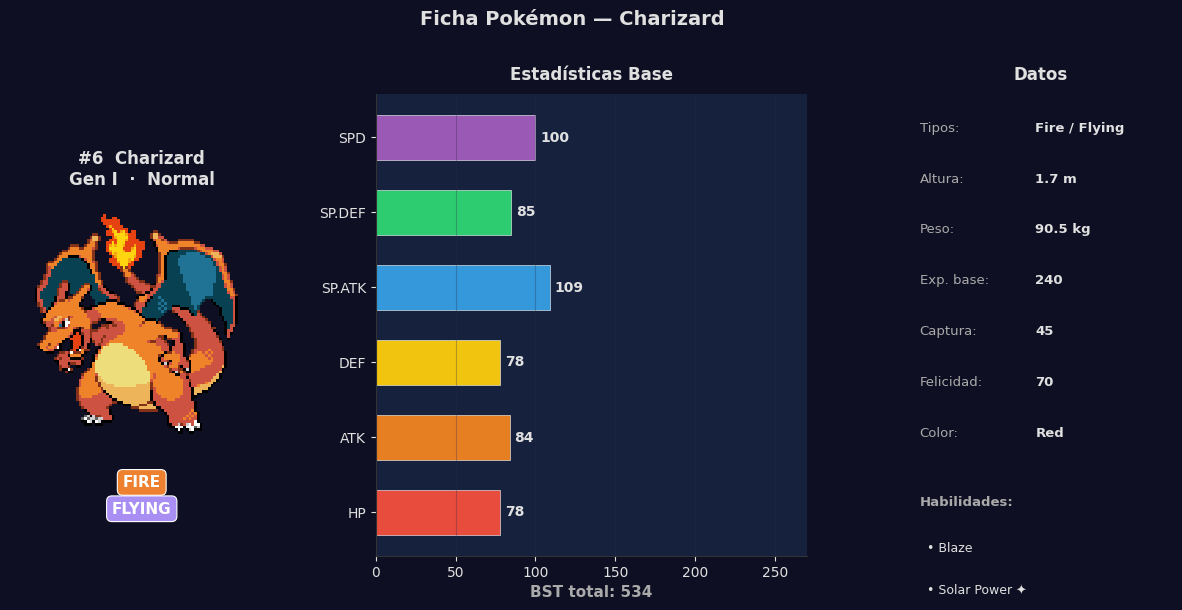

Tipos verificados (BD): fire / flying


In [20]:
# --- Ejemplos de verificación de tipos ---
ver_pokemon('charizard')   # Fire / Flying

/tmp/ipykernel_43459/3653900059.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


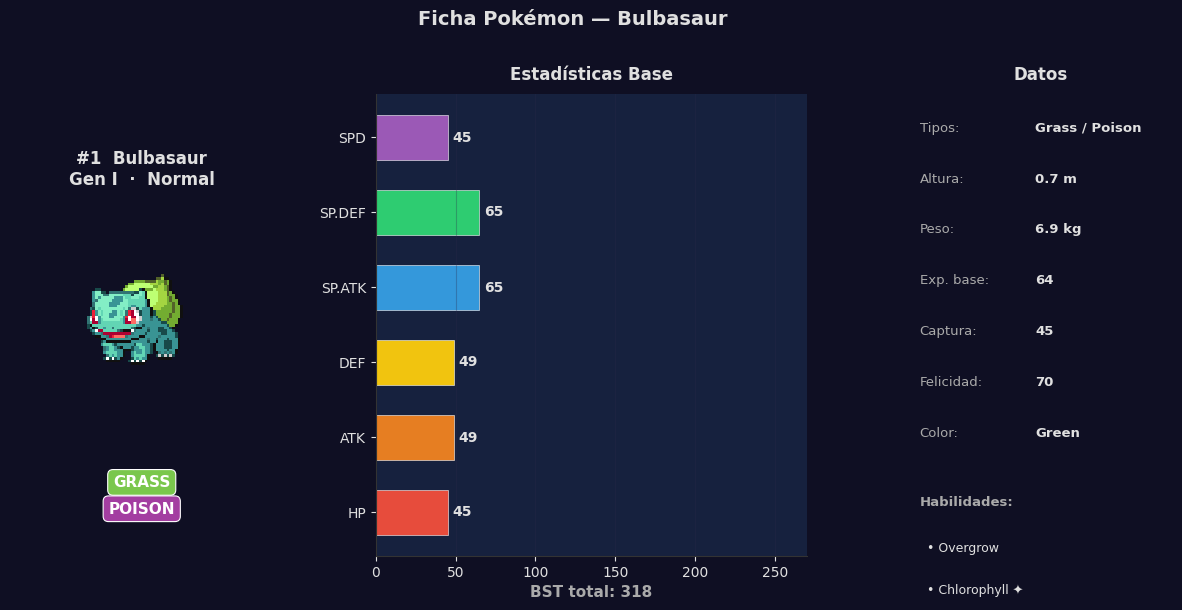

Tipos verificados (BD): grass / poison


In [21]:
ver_pokemon('bulbasaur')   # Grass / Poison

In [22]:
# Tabla de verificación: todos los Pokémon dual-tipo ordenados por ID
dual = pd.read_sql('''
    SELECT p.id, p.name,
           MAX(CASE WHEN pt.slot=1 THEN pt.type_name END) AS tipo1,
           MAX(CASE WHEN pt.slot=2 THEN pt.type_name END) AS tipo2
    FROM pokemon p
    JOIN pokemon_types pt ON p.id = pt.pokemon_id
    WHERE p.id < 10000
    GROUP BY p.id
    HAVING tipo2 IS NOT NULL
    ORDER BY p.id
''', con)

print(f"Total Pokémon con doble tipo: {len(dual)}")
dual.head(30)


Total Pokémon con doble tipo: 526


,id,name,tipo1,tipo2
0,1,bulbasaur,grass,poison
1,2,ivysaur,grass,poison
2,3,venusaur,grass,poison
3,6,charizard,fire,flying
4,12,butterfree,bug,flying
5,13,weedle,bug,poison
6,14,kakuna,bug,poison
7,15,beedrill,bug,poison
8,16,pidgey,normal,flying
9,17,pidgeotto,normal,flying


## 10. Gráficas Interactivas — Plotly

Plotly genera gráficas HTML en las que puedes pasar el cursor para ver datos por Pokémon,
hacer zoom con la rueda del ratón y doble clic para resetear.
Reutiliza el `df` ya filtrado a 1 025 formas base.

*(Compara la sección 3 y la sección 2 — mismos datos, distinta forma de explorarlos.)*


In [23]:
import plotly.express as px

ds_px = df[df['type1'].isin(MAIN) & df['weight_kg'].notna() & df['height_m'].notna()].copy()
ds_px = ds_px[(ds_px['weight_kg'] <= ds_px['weight_kg'].quantile(0.99)) &
              (ds_px['height_m']  <= ds_px['height_m'].quantile(0.99))]

fig = px.scatter(
    ds_px, x='weight_kg', y='height_m',
    color='type1',
    color_discrete_map=TYPE_COLORS,
    size='bst', size_max=18,
    hover_name='name',
    hover_data={'type1': True, 'type2': True, 'bst': True,
                'weight_kg': ':.1f', 'height_m': ':.1f'},
    labels={'weight_kg': 'Peso (kg)', 'height_m': 'Altura (m)',
            'type1': 'Tipo primario', 'bst': 'BST'},
    title='Peso vs Altura — Interactivo (Plotly)<br>'
          '<sup>Tamaño = BST | Color = tipo primario | Pasa el cursor para ver el nombre</sup>',
    template='plotly_dark',
)
fig.update_layout(legend_title_text='Tipo primario')
fig.show()


In [24]:
counts_px = (df[df['type1'].isin(MAIN)]['type1']
             .value_counts()
             .reset_index()
             .rename(columns={'type1': 'tipo', 'count': 'n'}))

fig2 = px.bar(
    counts_px.sort_values('n'), x='n', y='tipo',
    orientation='h',
    color='tipo',
    color_discrete_map=TYPE_COLORS,
    labels={'n': 'Pokémon', 'tipo': 'Tipo primario'},
    title='Distribución de Tipos Primarios — Interactivo (Plotly)',
    template='plotly_dark',
)
fig2.update_layout(showlegend=False)
fig2.show()


In [25]:
con.close()
print('Conexion cerrada.')

Conexion cerrada.


## 11. Consultas MongoDB

Mismos datos que el análisis SQL, pero consultados como **documentos desnormalizados**.  
Cada Pokémon es un solo objeto JSON con sus tipos, stats, habilidades, especie y movimientos embebidos — sin necesidad de JOINs.

> **Requisito:** ejecutar `python scripts/build_nosql.py` primero para cargar los datos.  
> Consulta `docs/MONGO_GUIDE.md` si MongoDB no está instalado todavía.